In [1]:
1.DATASET SELECTION

In [ ]:
1.1 Title: Flight Delay and Cancellation Analysis Using Exploratory Data Analysis (EDA)

In [ ]:
1.2 Objective

In [ ]:
The objective of this project is to analyze flight delay and cancellation patterns using Exploratory Data Analysis (EDA).

In [ ]:
1.3 Dataset Source

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
2. DATA LOADING

In [3]:
df = pd.read_csv(r"C:\Users\swapn\Downloads\archive (1)\flights_sample_3m.csv")
df.head()

,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,...,DIVERTED,CRS_ELAPSED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT
0,2019-01-09,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,1562,FLL,"Fort Lauderdale, FL",EWR,"Newark, NJ",...,0.0,186.0,176.0,153.0,1065.0,NaN,NaN,NaN,NaN,NaN
1,2022-11-19,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,1149,MSP,"Minneapolis, MN",SEA,"Seattle, WA",...,0.0,235.0,236.0,189.0,1399.0,NaN,NaN,NaN,NaN,NaN
2,2022-07-22,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,459,DEN,"Denver, CO",MSP,"Minneapolis, MN",...,0.0,118.0,112.0,87.0,680.0,NaN,NaN,NaN,NaN,NaN
3,2023-03-06,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,2295,MSP,"Minneapolis, MN",SFO,"San Francisco, CA",...,0.0,260.0,285.0,249.0,1589.0,0.0,0.0,24.0,0.0,0.0
4,2020-02-23,Spirit Air Lines,Spirit Air Lines: NK,NK,20416,407,MCO,"Orlando, FL",DFW,"Dallas/Fort Worth, TX",...,0.0,181.0,182.0,153.0,985.0,NaN,NaN,NaN,NaN,NaN


In [ ]:
3. DATASET OBSERVATION

In [4]:
df.shape

(3000000, 32)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000000 entries, 0 to 2999999
Data columns (total 32 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   FL_DATE                  object 
 1   AIRLINE                  object 
 2   AIRLINE_DOT              object 
 3   AIRLINE_CODE             object 
 4   DOT_CODE                 int64  
 5   FL_NUMBER                int64  
 6   ORIGIN                   object 
 7   ORIGIN_CITY              object 
 8   DEST                     object 
 9   DEST_CITY                object 
 10  CRS_DEP_TIME             int64  
 11  DEP_TIME                 float64
 12  DEP_DELAY                float64
 13  TAXI_OUT                 float64
 14  WHEELS_OFF               float64
 15  WHEELS_ON                float64
 16  TAXI_IN                  float64
 17  CRS_ARR_TIME             int64  
 18  ARR_TIME                 float64
 19  ARR_DELAY                float64
 20  CANCELLED                float64
 21  CANCELLA

In [9]:
df.describe()

,DOT_CODE,FL_NUMBER,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,TAXI_OUT,WHEELS_OFF,WHEELS_ON,TAXI_IN,CRS_ARR_TIME,...,DIVERTED,CRS_ELAPSED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT
count,3.000000e+06,3.000000e+06,3.000000e+06,2.922385e+06,2.922356e+06,2.921194e+06,2.921194e+06,2.920056e+06,2.920056e+06,3.000000e+06,...,3.000000e+06,2.999986e+06,2.913802e+06,2.913802e+06,3.000000e+06,533863.000000,533863.000000,533863.000000,533863.000000,533863.000000
mean,1.997629e+04,2.511536e+03,1.327062e+03,1.329776e+03,1.012333e+01,1.664305e+01,1.352361e+03,1.462500e+03,7.678982e+00,1.490561e+03,...,2.352000e-03,1.422758e+02,1.366205e+02,1.123108e+02,8.093616e+02,24.759086,3.985260,13.164728,0.145931,25.471282
std,3.772846e+02,1.747258e+03,4.858789e+02,4.993101e+02,4.925183e+01,9.192901e+00,5.008727e+02,5.272368e+02,6.269639e+00,5.115476e+02,...,4.844036e-02,7.155669e+01,7.167582e+01,6.975484e+01,5.878939e+02,71.771845,32.410796,33.161122,3.582053,55.766892
min,1.939300e+04,1.000000e+00,1.000000e+00,1.000000e+00,-9.000000e+01,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,...,0.000000e+00,1.000000e+00,1.500000e+01,8.000000e+00,2.900000e+01,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.979000e+04,1.051000e+03,9.150000e+02,9.160000e+02,-6.000000e+00,1.100000e+01,9.310000e+02,1.049000e+03,4.000000e+00,1.107000e+03,...,0.000000e+00,9.000000e+01,8.400000e+01,6.100000e+01,3.770000e+02,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.993000e+04,2.152000e+03,1.320000e+03,1.323000e+03,-2.000000e+00,1.400000e+01,1.336000e+03,1.501000e+03,6.000000e+00,1.516000e+03,...,0.000000e+00,1.250000e+02,1.200000e+02,9.500000e+01,6.510000e+02,4.000000,0.000000,0.000000,0.000000,0.000000
75%,2.036800e+04,3.797000e+03,1.730000e+03,1.739000e+03,6.000000e+00,1.900000e+01,1.752000e+03,1.908000e+03,9.000000e+00,1.919000e+03,...,0.000000e+00,1.720000e+02,1.670000e+02,1.420000e+02,1.046000e+03,23.000000,0.000000,17.000000,0.000000,30.000000
max,2.045200e+04,9.562000e+03,2.359000e+03,2.400000e+03,2.966000e+03,1.840000e+02,2.400000e+03,2.400000e+03,2.490000e+02,2.400000e+03,...,1.000000e+00,7.050000e+02,7.390000e+02,6.920000e+02,5.812000e+03,2934.000000,1653.000000,1741.000000,1185.000000,2557.000000


In [6]:
df.isnull().sum()

FL_DATE                          0
AIRLINE                          0
AIRLINE_DOT                      0
AIRLINE_CODE                     0
DOT_CODE                         0
FL_NUMBER                        0
ORIGIN                           0
ORIGIN_CITY                      0
DEST                             0
DEST_CITY                        0
CRS_DEP_TIME                     0
DEP_TIME                     77615
DEP_DELAY                    77644
TAXI_OUT                     78806
WHEELS_OFF                   78806
WHEELS_ON                    79944
TAXI_IN                      79944
CRS_ARR_TIME                     0
ARR_TIME                     79942
ARR_DELAY                    86198
CANCELLED                        0
CANCELLATION_CODE          2920860
DIVERTED                         0
CRS_ELAPSED_TIME                14
ELAPSED_TIME                 86198
AIR_TIME                     86198
DISTANCE                         0
DELAY_DUE_CARRIER          2466137
DELAY_DUE_WEATHER   

In [ ]:
4. DATA CLEANING & PREPARATION

In [ ]:
4.1. Check Dataset Shape

In [7]:
df.shape

(3000000, 32)

In [ ]:
4.2. Identifying And Handling Missing Values

In [8]:
df.isnull().sum()

FL_DATE                          0
AIRLINE                          0
AIRLINE_DOT                      0
AIRLINE_CODE                     0
DOT_CODE                         0
FL_NUMBER                        0
ORIGIN                           0
ORIGIN_CITY                      0
DEST                             0
DEST_CITY                        0
CRS_DEP_TIME                     0
DEP_TIME                     77615
DEP_DELAY                    77644
TAXI_OUT                     78806
WHEELS_OFF                   78806
WHEELS_ON                    79944
TAXI_IN                      79944
CRS_ARR_TIME                     0
ARR_TIME                     79942
ARR_DELAY                    86198
CANCELLED                        0
CANCELLATION_CODE          2920860
DIVERTED                         0
CRS_ELAPSED_TIME                14
ELAPSED_TIME                 86198
AIR_TIME                     86198
DISTANCE                         0
DELAY_DUE_CARRIER          2466137
DELAY_DUE_WEATHER   

In [ ]:
4.3. Handling

In [10]:
df = df.dropna(subset=["DEP_DELAY", "ARR_DELAY"])

In [ ]:
4.4 Check For Duplicate Values And Remove Them If Present

In [11]:
df.duplicated().sum()

0

In [13]:
4.5. Outlier Detection & Treatment

In [12]:
Q1 = df['DEP_DELAY'].quantile(0.25)
Q3 = df['DEP_DELAY'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['DEP_DELAY'] >= lower) & (df['DEP_DELAY'] <= upper)]

print("Dataset shape after outlier removal:", df.shape)

Dataset shape after outlier removal: (2523525, 32)


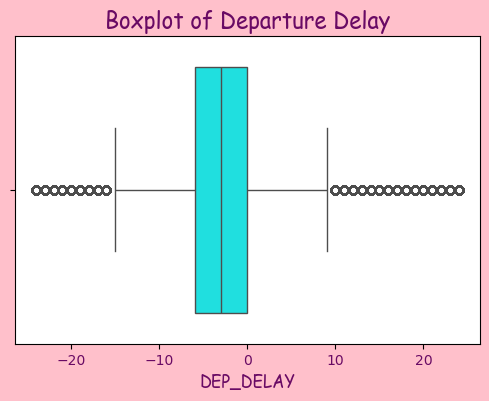

In [13]:
plt.figure(figsize=(6,4), facecolor='pink')
sns.boxplot(x=df['DEP_DELAY'], color='cyan')
plt.title('Boxplot of Departure Delay',color='#690a64',fontfamily='cursive',fontsize=16)
plt.xlabel('DEP_DELAY',fontfamily='cursive',fontsize=12,color='#690a64')
plt.xticks(color='#690a64')
plt.show()

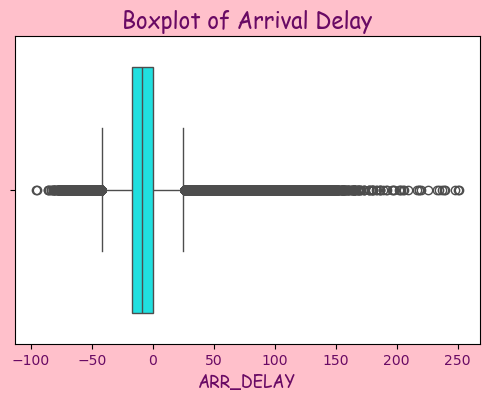

In [14]:
plt.figure(figsize=(6,4), facecolor='pink')
sns.boxplot(x=df['ARR_DELAY'], color='cyan')
plt.title('Boxplot of Arrival Delay',color='#690a64',fontfamily='cursive',fontsize=16)
plt.xlabel('ARR_DELAY',fontfamily='cursive',fontsize=12,color='#690a64')
plt.xticks(color='#690a64')
plt.show()

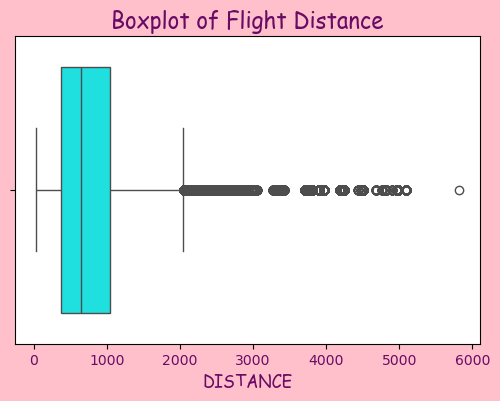

In [15]:
plt.figure(figsize=(6,4), facecolor='pink')
sns.boxplot(x=df['DISTANCE'], color='cyan')
plt.title('Boxplot of Flight Distance',color='#690a64',fontfamily='cursive',fontsize=16)
plt.xlabel('DISTANCE',fontfamily='cursive',fontsize=12,color='#690a64')
plt.xticks(color='#690a64')
plt.show()

In [ ]:
4.6 Checking whether the dataset is imbalanced or not

In [16]:
df["CANCELLED"].value_counts()

CANCELLED
0.0    2523525
Name: count, dtype: int64

In [17]:
df["CANCELLED"].value_counts(normalize=True) * 100

CANCELLED
0.0    100.0
Name: proportion, dtype: float64

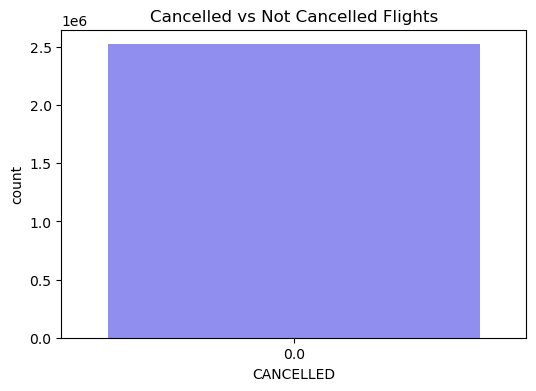

In [19]:
plt.figure(figsize=(6,4))
sns.countplot(x="CANCELLED", data=df, hue="CANCELLED", palette="cool", legend=False)
plt.title("Cancelled vs Not Cancelled Flights")
plt.show()

In [ ]:
5. EXPLORATORY DATA ANALYSIS(EDA)

In [ ]:
5.1 Univariate Analysis

In [ ]:
5.1.1 Distribution of Departure Delay

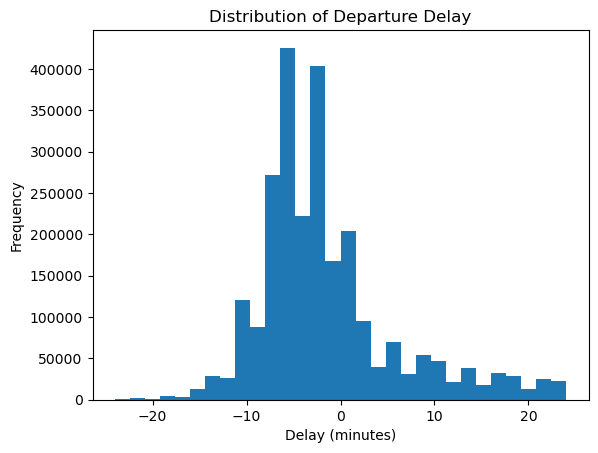

In [20]:
plt.hist(df["DEP_DELAY"], bins=30)
plt.title("Distribution of Departure Delay")
plt.xlabel("Delay (minutes)")
plt.ylabel("Frequency")
plt.show()

In [ ]:
5.1.2 Cancellation Count

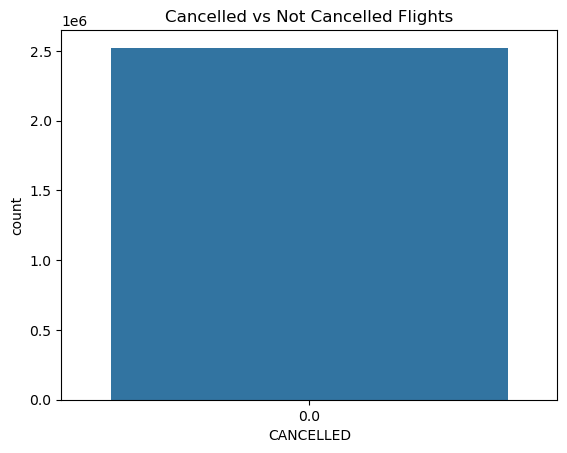

In [21]:
sns.countplot(x="CANCELLED", data=df)
plt.title("Cancelled vs Not Cancelled Flights")
plt.show()

In [ ]:
5.2 BIVARIATE ANALYSIS

In [ ]:
5.2.1 DEP_DELAY vs ARR_DELAY

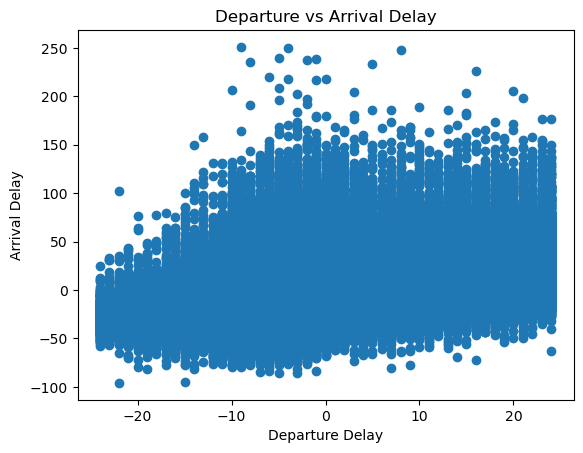

In [22]:
plt.scatter(df["DEP_DELAY"], df["ARR_DELAY"])
plt.xlabel("Departure Delay")
plt.ylabel("Arrival Delay")
plt.title("Departure vs Arrival Delay")
plt.show()

In [ ]:
5.2.2 Airline vs Average Delay

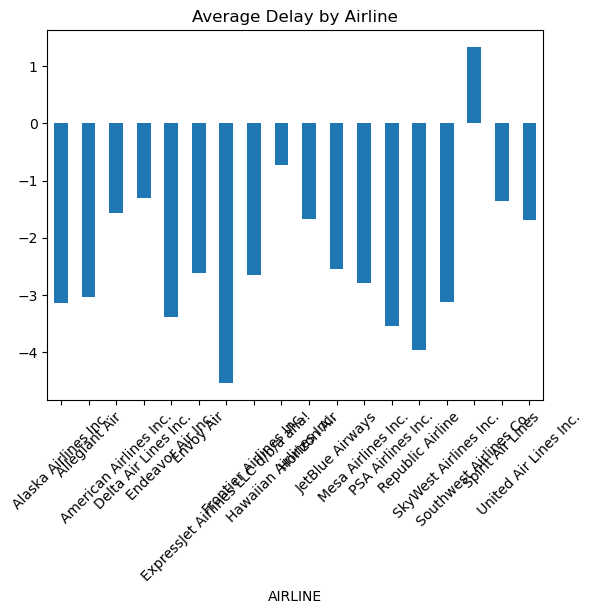

In [23]:
df.groupby("AIRLINE")["DEP_DELAY"].mean().plot(kind="bar")
plt.title("Average Delay by Airline")
plt.xticks(rotation=45)
plt.show()

In [ ]:
5.3 MULTIVARIATE ANALYSIS

In [ ]:
5.3.1 Correlation Heatmap

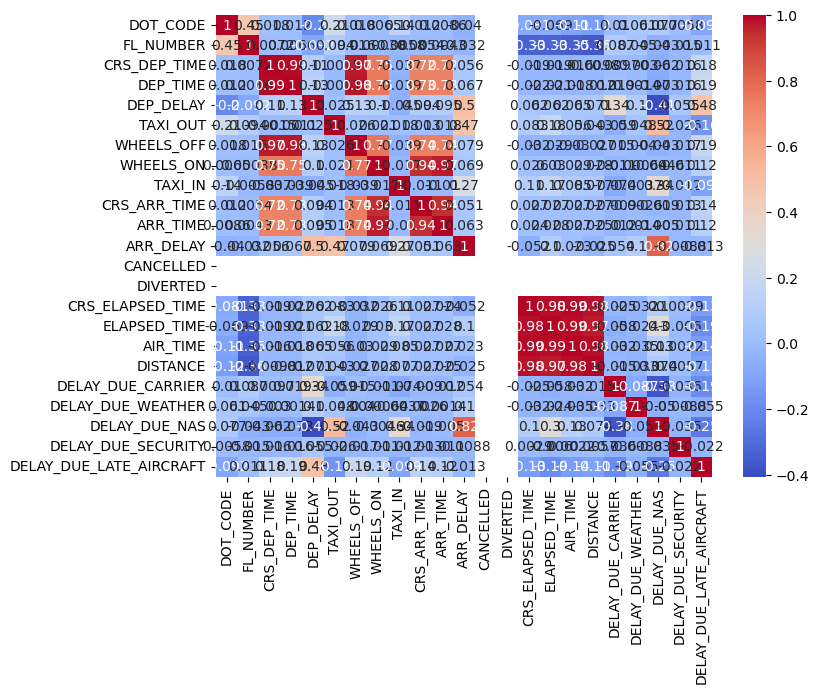

In [24]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

In [ ]:
6. PIVOT TABLES

In [ ]:
6.1 Average Departure Delay by Airline and Month

In [32]:
df["FL_DATE"] = pd.to_datetime(df["FL_DATE"])
df["MONTH"] = df["FL_DATE"].dt.month
pivot1 = pd.pivot_table(
    df,
    values="DEP_DELAY",
    index="AIRLINE",
    columns="MONTH",
    aggfunc="mean"
)
pivot1

MONTH,1,2,3,4,5,6,7,8,9,10,11,12
AIRLINE,,,,,,,,,,,,
Alaska Airlines Inc.,-3.875836,-3.819437,-3.412204,-3.399513,-3.213258,-2.213746,-2.426969,-2.554593,-3.888232,-3.645196,-3.283097,-1.995871
Allegiant Air,-3.909745,-3.660553,-3.637208,-2.439952,-3.149635,-1.911221,-2.605732,-3.493575,-3.786685,-2.596167,-2.980216,-2.775342
American Airlines Inc.,-2.244147,-1.615829,-1.986917,-1.877327,-1.311240,-0.258739,-0.860689,-1.621807,-2.373154,-1.602841,-1.866540,-1.222237
Delta Air Lines Inc.,-1.687585,-1.498163,-1.512538,-1.444246,-0.985915,-0.376570,-0.633893,-1.187205,-2.151829,-1.847110,-1.741102,-0.733816
Endeavor Air Inc.,-3.698630,-3.422987,-3.795866,-3.454798,-3.426322,-2.814865,-2.867553,-3.194966,-3.789734,-3.576787,-3.591176,-2.896510
Envoy Air,-2.810662,-2.365191,-3.145428,-3.029607,-2.498856,-1.641772,-2.134419,-2.656142,-3.353793,-2.918308,-2.617397,-2.105644
ExpressJet Airlines LLC d/b/a aha!,-4.467332,-4.403770,-5.357390,-5.651948,-4.815368,-3.273138,-4.301395,-4.521964,-4.248028,-3.981236,-4.701092,-3.758099
Frontier Airlines Inc.,-3.267306,-2.684120,-3.000000,-2.515321,-2.226122,-1.745759,-2.248268,-2.405045,-3.698580,-2.879546,-3.063569,-2.196735
Hawaiian Airlines Inc.,-1.356130,-1.244223,-0.713532,-0.238286,-0.405308,0.204502,-0.007983,-0.853201,-2.244033,-0.853973,-1.279275,0.035627


In [ ]:
Interpretation

In [ ]:
The pivot table shows the average departure delay across different airlines and months.
  -Some airlines have higher average delays compared to others.
  -Certain months show increased delay values.
  -Delay patterns vary seasonally.
This suggests that airline performance and seasonal factors influence departure delays.

In [ ]:
6.2 Airports with Highest Number of Flight Cancellations

In [33]:
pivot2 = pd.pivot_table(df,
                        values="CANCELLED",
                        index="ORIGIN",
                        aggfunc="sum")

pivot2.sort_values(by="CANCELLED", ascending=False).head()

,CANCELLED
ORIGIN,
ABE,0.0
MVY,0.0
OME,0.0
OMA,0.0
OKC,0.0


In [ ]:
Interpretation

In [ ]:
The pivot table shows the total number of cancelled flights for each origin airport.
  -Some airports have significantly higher cancellations.
  -High-traffic airports tend to show more cancellations.
  -Cancellation frequency differs across locations.
This suggests airport traffic and operational conditions may impact cancellation rates.

In [ ]:
7.SUMMARY

Most flights operate without cancellation, indicating cancellations are relatively rare.
Departure and arrival delays show a positive relationship.
A small number of flights experience extremely high delays (outliers).
Certain airlines exhibit consistently higher average departure delays.
Delay patterns vary across months, suggesting seasonal influence.
Some origin airports report significantly higher cancellation counts.
Delay occurrence appears to be influenced by multiple operational and seasonal factors rather than a single dominant variable.

In [35]:
df.columns

Index(['FL_DATE', 'AIRLINE', 'AIRLINE_DOT', 'AIRLINE_CODE', 'DOT_CODE',
       'FL_NUMBER', 'ORIGIN', 'ORIGIN_CITY', 'DEST', 'DEST_CITY',
       'CRS_DEP_TIME', 'DEP_TIME', 'DEP_DELAY', 'TAXI_OUT', 'WHEELS_OFF',
       'WHEELS_ON', 'TAXI_IN', 'CRS_ARR_TIME', 'ARR_TIME', 'ARR_DELAY',
       'CANCELLED', 'CANCELLATION_CODE', 'DIVERTED', 'CRS_ELAPSED_TIME',
       'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE', 'DELAY_DUE_CARRIER',
       'DELAY_DUE_WEATHER', 'DELAY_DUE_NAS', 'DELAY_DUE_SECURITY',
       'DELAY_DUE_LATE_AIRCRAFT', 'MONTH'],
      dtype='object')